<a href="https://colab.research.google.com/github/Pete-Reseacher/python-geoscience/blob/main/WEEK3_EXCERCISE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load the well_A.las file

STEP 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import lasio as ls
import numpy as np

In [ ]:
# Load the LAS file
las = ls.read("Well_A.las")
df = las.df().reset_index()
df.replace(las.well.NULL.value, np.nan, inplace=True)

In [ ]:
df

,DEPT,CALF,SON3,FDC,VSH,RT,POR,GR_NM
0,4901.0,NaN,NaN,1.5551,NaN,NaN,NaN,NaN
1,4901.5,NaN,NaN,1.5553,NaN,NaN,NaN,NaN
2,4902.0,NaN,NaN,1.5812,NaN,NaN,NaN,NaN
3,4902.5,NaN,NaN,1.6205,NaN,NaN,NaN,NaN
4,4903.0,NaN,NaN,1.6645,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
6176,7989.0,NaN,NaN,NaN,NaN,4.1563,NaN,NaN
6177,7989.5,NaN,NaN,NaN,NaN,4.1563,NaN,NaN
6178,7990.0,NaN,NaN,NaN,NaN,4.1564,NaN,NaN
6179,7990.5,NaN,NaN,NaN,NaN,4.1565,NaN,NaN


# STATISTICAL FACIES DISCRIMINATION¶ | Histogram of Gammma ray (GR_NM)
# STEP 2

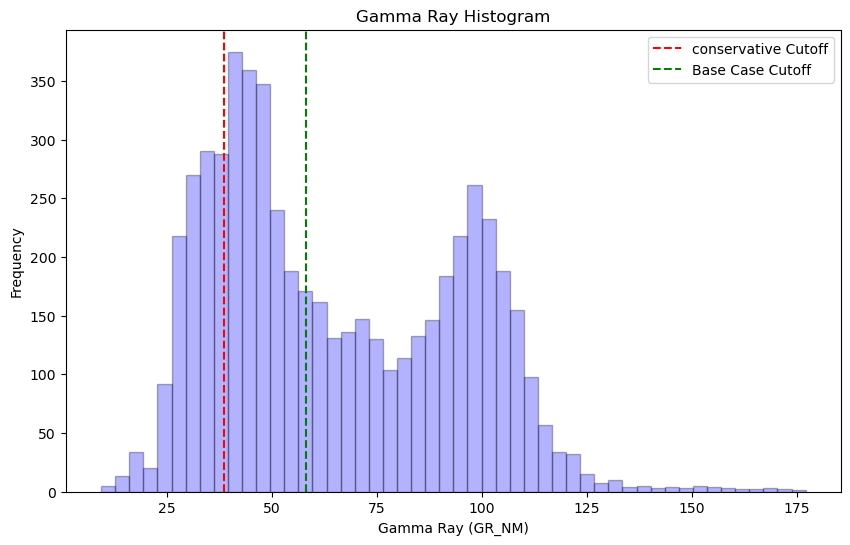

Conservative Cutoff: 38.53
Base Case Cutoff: 57.97


In [ ]:
plt.figure(figsize=(10,6))

# Plot a histogram
plt.hist(df["GR_NM"].dropna(), bins=50, alpha=0.3, color="blue", edgecolor="black")
plt.xlabel("Gamma Ray (GR_NM)")
plt.ylabel("Frequency")
plt.title("Gamma Ray Histogram")


# Calculate percentiles
conservative_cutoff = np.percentile(df["GR_NM"].dropna(), 20)
base_case_cutoff = np.percentile(df["GR_NM"].dropna(), 50)

plt.axvline(conservative_cutoff, color="red", linestyle="--", label="conservative Cutoff")
plt.axvline(base_case_cutoff, color="green", linestyle="--", label="Base Case Cutoff")
plt.legend()
plt.show()


print(f"Conservative Cutoff: {conservative_cutoff:.2f}")
print(f"Base Case Cutoff: {base_case_cutoff:.2f}")

#The cutoffs:
#Conservative cutoff(20th percentile):38.53 --> This suggests 20% of the data is below this GR value. Likely represents "Cleaner sand".

#Base case cutoff(50th percentile): 57.97 --> This suggests 50% of the data is below this GR value. Typical sand/shale cutoff often sits around here if sand/shale proportions are roughly equal.

# Calculate the Reservoir Quality Index( RQI)
# STEP 3

# NORMALIZED GR = (GR - GR_MIN)/(GR_MAX - GR_MIN)

In [ ]:
gr_min = df["GR_NM"].min()
gr_max = df["GR_NM"].max()

df["GR_Norm"] = (df["GR_NM"] - gr_min)/(gr_max - gr_min)

df [df["GR_NM"] >= 0]

# RQI = POROCITY * 1 - df["GR_Norm"]
df["RQI"] = df["POR"] * (1 - df["GR_Norm"])
df["RQI"].describe()

count    3842.000000
mean        0.194180
std         0.077771
min         0.000000
25%         0.166757
50%         0.212712
75%         0.251891
max         0.297144
Name: RQI, dtype: float64

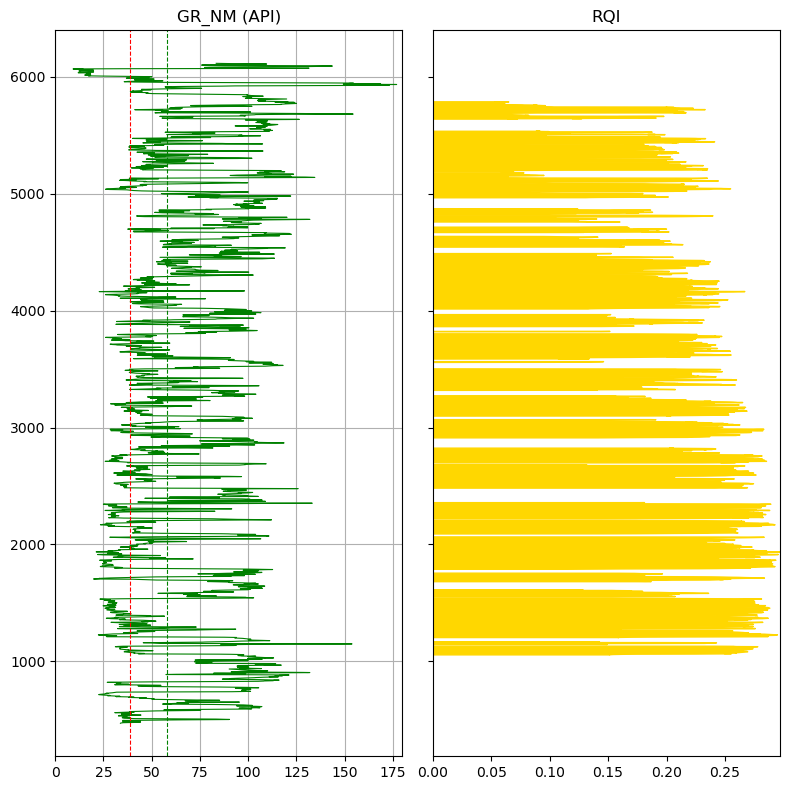

        GR_NM       RQI     POR
1131  44.2729  0.000000  0.0000
1132  56.7960  0.000000  0.0000
2065  47.2930  0.000000  0.0000
2066  51.1172  0.000000  0.0000
2204  47.2344  0.000000  0.0000
...       ...       ...     ...
5713  55.8590  0.103418  0.1432
5714  53.5290  0.106731  0.1450
5715  51.1991  0.110544  0.1474
5716  46.5995  0.112563  0.1448
5717  42.0000  0.163209  0.2028

[258 rows x 3 columns]


In [ ]:
fig, ax = plt.subplots(1, 2, figsize= (8,8), sharey=True)

ax[0].plot(df["GR_NM"], df.index, color="green", lw=0.8)
ax[0].axvline(conservative_cutoff, color="red", ls="--", lw=0.8, label="conservative_cutoff")
ax[0].axvline(base_case_cutoff, color="green", ls="--", lw=0.8, label="base_case_cutoff")
ax[0].set_title("GR_NM (API)")
ax[0].set_xlim(0,180)
ax[0].grid(True)
ax[0].invert_yaxis()

#ax[1].plot(df["ROI"], df{"DEPT"], color = "gold")
ax[1].fill_betweenx(df.index, 0, df["RQI"], color="gold")
ax[1].set_xlim(0,  df["RQI"].max())
ax[1].set_title("RQI")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()


# for low GR but low RQI zone
low_gr_low_rqi_zone = df[(df["GR_NM"] < base_case_cutoff) & (df["RQI"] < df["RQI"].mean())]
print(low_gr_low_rqi_zone[["GR_NM", "RQI","POR"]])

#Check the outputm -- Likely the porosity is low in that zone,making the rock quality poor despite being "clean" sand.

#The low RQI with low GR might be due too:
#Very low porosity(0.0000): likely non- reservoir ot tight rock.
#Moderate porosity(~14%): But maybe not enough permeability or hydrocarbon saturation.

# STEP 4

In [ ]:
 # Calculate Net Pay thickness
df["Case_A"] = (df["GR_NM"] < conservative_cutoff) & (df["POR"] > 0.18)
df["Case_B"] = (df["GR_NM"] < base_case_cutoff) & (df["POR"] > 0.12)

# Calculate thickness (assuming depth interval is constant)
depth_interval = df.index[1] - df.index[0]
net_pay_A = df["Case_A"]. sum() * depth_interval
net_pay_B = df["Case_B"]. sum() * depth_interval

print(f"Net Pay (Case A - Conservative): {net_pay_A:.2f} m")
print(f"Net Pay (Case B - Optimistic): {net_pay_B:.2f} m")

# Brief report
print('\nComparison:')
print(f"Case A (Conservative) has stricter criteria (GR < {conservative_cutoff:.2f} and Porosity > 18%)")
print(f"Case B (Optimistic) has looser criteria (GR < {base_case_cutoff:.2f} and Porosity > 12%)")
print(f"Net Pay is {net_pay_B / net_pay_A:.2f}x higher in the Optimistic case")

Net Pay (Case A - Conservative): 927.00 m
Net Pay (Case B - Optimistic): 2414.00 m

Comparison:
Case A (Conservative) has stricter criteria (GR < 38.53 and Porosity > 18%)
Case B (Optimistic) has looser criteria (GR < 57.97 and Porosity > 12%)
Net Pay is 2.60x higher in the Optimistic case
